In [1]:
from pathlib import Path
import json
import requests
from PIL import Image
from io import BytesIO

import pandas as pd


BASE_DIR = Path() / "data"

hackaton_advertisements = BASE_DIR / "hackaton_advertisements.csv"
hackaton_advertisements_with_id = BASE_DIR / "hackaton_advertisements_with_id.csv"
advertisement_photos = BASE_DIR / "advertisement_photos.csv"

df = pd.read_csv(hackaton_advertisements)
df_with_id = pd.read_csv(hackaton_advertisements_with_id)
df_photos = pd.read_csv(advertisement_photos)

In [2]:
display(df_with_id.head())
display(df_photos.head())

,advertisement_id,status,title,description,original_price,sold_price,sold_via_bargain,created_at,modified_at,category_id
0,57b1df55-7aaf-488d-bd18-f9e058841365,DELETED,"Томас Майн Рід ""Вершник без голови"" книга",Легендарний роман Томаса Майна Ріда про таємни...,140.0,140,False,2026-01-06 21:19:53.606429 +00:00,2026-01-12 12:53:37.997077 +00:00,795
1,9aaa1ac8-5d39-4672-bc26-d31cf532115f,DELETED,"Сороконожки Nike Tiempo оригінал, стан 9/10",Оригінальні сороконожки Nike Tiempo в чорному ...,2500.0,2500,False,2025-12-21 22:24:39.005006 +00:00,2026-03-26 22:09:42.097405 +00:00,512
2,aec79e38-bf5d-4ef8-a31c-b35fe86e38cf,DELETED,Модель Boeing B-52 Stratofortress USAF 1:200 м...,Металева модель легендарного стратегічного бом...,1500.0,1500,False,2026-01-06 08:43:11.716623 +00:00,2026-01-23 15:50:48.666247 +00:00,1677
3,c24b269c-c3a9-411e-84d9-0c2c32011ccf,DELETED,"Кросівки жіночі шкіра+замша з зіркою, платформ...",Стильні жіночі кросівки з комбінованих матеріа...,290.0,290,False,2026-01-21 19:52:14.280130 +00:00,2026-03-16 17:14:37.775775 +00:00,512
4,beb02af1-61dc-4914-8a32-0fae8c91c9c3,DELETED,Вогнепальна зброя світу - енциклопедія Ексмо 2013,Фундаментальна енциклопедія з історії вогнепал...,1800.0,1800,False,2026-02-01 11:22:35.883203 +00:00,2026-03-19 07:28:24.363539 +00:00,795


,advertisement_id,s3_key
0,00014026-c305-46fd-96f0-6ac4e38e96b5,0ba04b85-80b1-4e3e-8963-328fd97b2f58
1,00014026-c305-46fd-96f0-6ac4e38e96b5,d21f2caf-0d26-4b10-bf21-93a1e3fb51ba
2,00014026-c305-46fd-96f0-6ac4e38e96b5,bef057d8-21c0-43b9-b3b9-1a2afb793cd1
3,00014026-c305-46fd-96f0-6ac4e38e96b5,aed52d42-7f1c-4607-b1bb-931b1ae5e805
4,00014026-c305-46fd-96f0-6ac4e38e96b5,9a917cd4-bfc3-483a-ae2c-747cb4051598


In [3]:
df_with_id[df_with_id["category_id"] == 1320]

,advertisement_id,status,title,description,original_price,sold_price,sold_via_bargain,created_at,modified_at,category_id
467,c93db175-67d9-4736-88b1-52435b82f3f2,DELETED,"Офісне крісло рожеве з екошкіри, регульоване, ...",Стильне офісне крісло з оригінальним дизайном ...,1350.0,1350,False,2026-01-12 17:27:19.563690 +00:00,2026-03-06 20:07:17.409391 +00:00,1320
601,0be0ac4e-abc0-4345-9249-b2f1334687d8,DELETED,"Офісне крісло чорне з екошкіри, регульоване, с...",Офісне крісло з чорної екошкіри в відмінному с...,1500.0,1500,False,2026-01-12 17:47:44.951963 +00:00,2026-01-12 17:48:56.786185 +00:00,1320
631,5874f52a-6fae-4894-a03e-c26ac7ebe17d,DELETED,Геймерське крісло Nowy Styl Hexter чорно-черво...,Ігрове крісло Nowy Styl Hexter у стильному чор...,5000.0,5000,False,2026-03-05 07:32:29.658403 +00:00,2026-03-05 07:34:01.960606 +00:00,1320
720,42060961-91f2-426d-bc5a-bc731f94d2be,SOLD,"Офісне крісло BONRO з екошкіри, коричневе, б/в",Офісне крісло бренду BONRO з екошкіри коричнев...,1499.0,1324,True,2025-12-16 13:34:41.266109 +00:00,2025-12-31 09:20:14.871215 +00:00,1320
820,0ec5a20f-b9f0-4244-8e77-0d882144faed,DELETED,"Офісний стілець з м'якою оббивкою, чорний",Практичний офісний стілець у хорошому стані.\n...,400.0,400,False,2025-12-20 04:08:46.010811 +00:00,2025-12-30 13:20:38.206254 +00:00,1320
...,...,...,...,...,...,...,...,...,...,...
59474,38910a4e-6d9e-476a-85d2-7205d85d66af,DELETED,"Геймерське крісло Cougar Armor PRO Black, ідеа...",Преміальне геймерське крісло Cougar Armor PRO ...,8499.0,8499,False,2025-12-12 13:02:45.638690 +00:00,2025-12-30 13:16:13.024643 +00:00,1320
59514,0ef85fdf-1b36-490a-9771-695a453df3d1,DELETED,Геймерське крісло Comfort Game червоне з підст...,Геймерське крісло Comfort Game в червоно-чорно...,3500.0,3500,False,2025-12-09 12:09:45.881364 +00:00,2026-02-03 06:02:26.167473 +00:00,1320
59518,c7709a5b-8726-4208-b97c-065e7288c045,DELETED,Професійне крісло для перукарні з регулюванням...,Спеціалізоване крісло для салонів краси та пер...,3000.0,3000,False,2025-12-19 09:24:58.399756 +00:00,2026-03-23 17:54:06.593434 +00:00,1320
59574,ffbc8848-a5fb-402b-92cf-400a8cf5aa09,DELETED,Крісло офісне BONRO чорне,Офісне крісло BONRO в ідеальному стані — не ви...,1100.0,1100,False,2026-02-04 17:00:05.636906 +00:00,2026-02-07 19:12:03.049412 +00:00,1320


In [4]:
df_with_id[(df_with_id["status"] == "SOLD") & (df_with_id["original_price"] > df_with_id["sold_price"]) & (df_with_id["category_id"] == 1320)]

,advertisement_id,status,title,description,original_price,sold_price,sold_via_bargain,created_at,modified_at,category_id
720,42060961-91f2-426d-bc5a-bc731f94d2be,SOLD,"Офісне крісло BONRO з екошкіри, коричневе, б/в",Офісне крісло бренду BONRO з екошкіри коричнев...,1499.0,1324,True,2025-12-16 13:34:41.266109 +00:00,2025-12-31 09:20:14.871215 +00:00,1320
3661,125c6f58-36ec-42b1-923b-0a33b51decb2,SOLD,4 стільці б/в з м'якою оббивкою та дерев'яними...,Комплект з 4 стільців у доброму стані для вико...,2000.0,1700,True,2025-12-19 06:58:23.290177 +00:00,2025-12-22 15:40:10.028723 +00:00,1320
6386,4eb4245b-abee-48ce-8c1a-6b615c366622,SOLD,Стілець косметологічний з підйомним механізмом...,Професійний косметологічний стілець у хорошому...,700.0,600,True,2026-01-04 12:09:00.051664 +00:00,2026-01-14 11:40:09.309454 +00:00,1320
8436,88cb5869-873b-4abf-b920-c95c478143eb,SOLD,Офісне крісло Barsky Butterfly Green з механіз...,Ергономічне офісне крісло з інноваційним механ...,3500.0,3050,True,2025-12-13 17:27:19.662840 +00:00,2025-12-16 18:20:09.743240 +00:00,1320
10138,bb0a2454-39bc-417d-a57f-7bcf3e470185,SOLD,Ергономічне офісне крісло з сітчастою спинкою ...,"Нове офісне крісло з ергономічним дизайном, не...",7999.0,6049,True,2025-12-22 10:17:42.259512 +00:00,2025-12-30 14:20:24.070699 +00:00,1320
13441,8cade346-5f13-4c96-bdb1-c44cc934a0af,SOLD,Офісне крісло SAMBA GTP Nowy Style чорне з під...,Офісне крісло SAMBA GTP від Nowy Style з чорно...,1200.0,1000,True,2026-01-13 10:11:01.441106 +00:00,2026-01-17 13:40:09.916828 +00:00,1320
16953,4a90607d-9995-4c3b-bedc-0a164f172fd7,SOLD,Офісне крісло Tehforward Ксенон з підголовнико...,Ергономічне офісне крісло з повним комплектом ...,4500.0,4000,True,2026-02-01 10:18:19.061517 +00:00,2026-03-13 12:20:11.676747 +00:00,1320
23077,910e7228-41ca-4649-9873-6b4291908d08,SOLD,"Ігрове крісло з підставкою для ніг, тканинна о...",Ігрове крісло в гарному стані з тканинною обши...,2800.0,2400,True,2026-01-30 21:41:57.868715 +00:00,2026-02-05 17:40:09.880587 +00:00,1320
26861,7ad7fb6f-e2b5-4c8b-8411-18f66c8fa4fd,SOLD,Обідній стілець ЕНРІКО синій з м'якою оббивкою,Стильний обідній стілець ЕНРІКО в синьому коль...,900.0,650,True,2025-12-27 15:36:35.651068 +00:00,2026-01-14 15:00:15.404221 +00:00,1320
29315,fef30b89-a056-46dc-92fe-14cb681415b8,SOLD,Ігрове крісло RZTK з підтримкою спини та підло...,"Є класне Крісло, все працює, є 2 подушки, кача...",3000.0,2100,True,2026-02-06 19:12:31.245591 +00:00,2026-02-24 16:40:12.323297 +00:00,1320


In [5]:
print(df_with_id.iloc[53086]["description"])

Офісне крісло в робочому стані за доступною ціною.

Особливості:
• Чорне оббивання з текстильними вставками
• Хромована п'ятипроменева база з колесами
• Регульована висота сидіння
• Підлокітники з м'якими накладками
• Поворотний механізм

Стан: є потертості на сидінні та спинці, всі механізми працюють. Підходить для офісу або домашнього робочого місця.

Готове до використання.


In [6]:
id = 53086

df_id = df_with_id.iloc[id]["advertisement_id"]

df_id

'5d4807a6-6e7a-40db-ab66-0451c6e9c2d8'

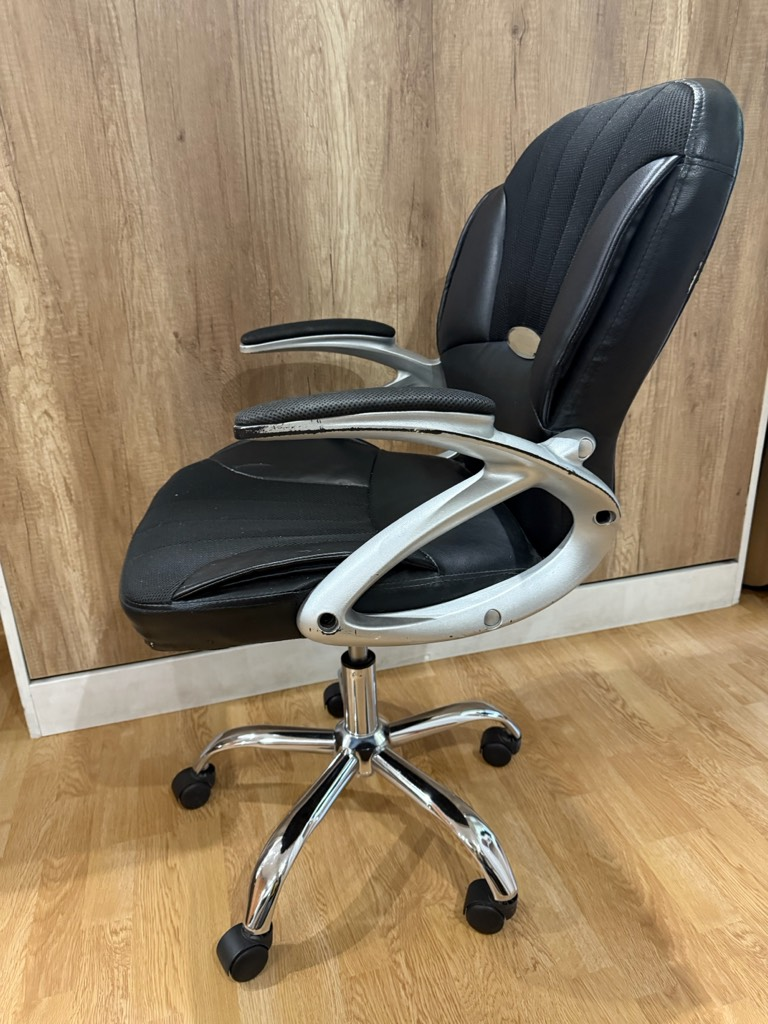

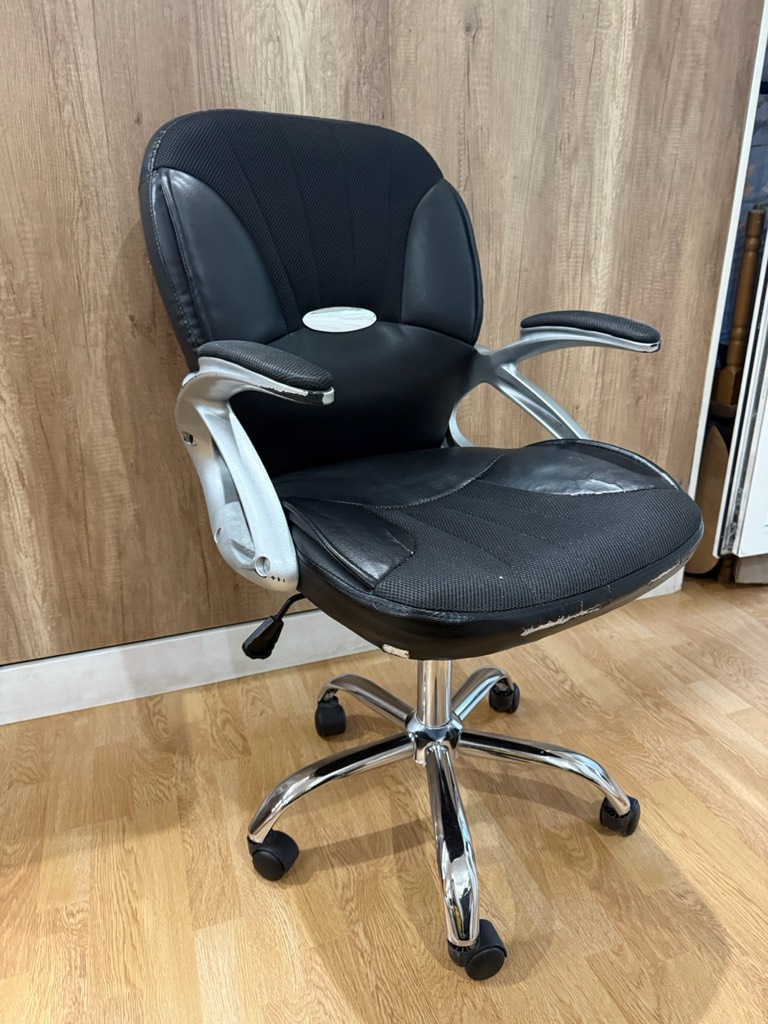

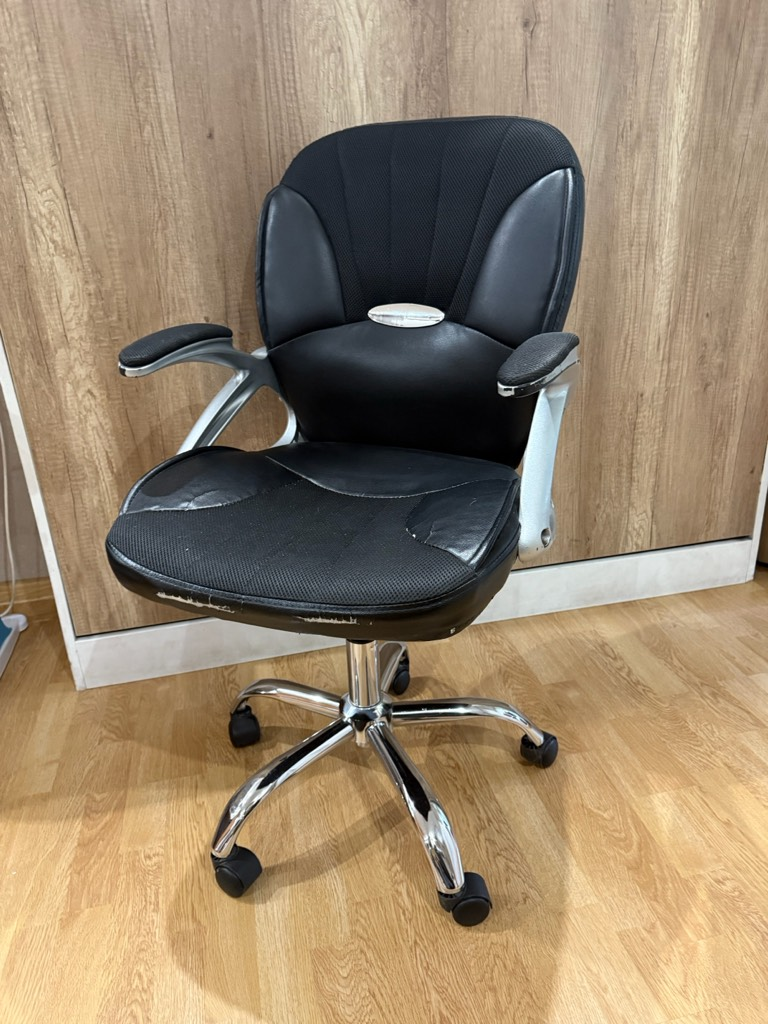

In [7]:
for i in df_photos[df_photos["advertisement_id"] == df_id]["s3_key"]:
    
    res = requests.get(f"https://resale-media.monobazar.com.ua/{i}")

    with Image.open(BytesIO(res.content)) as img:
        display(img)

In [24]:
import ollama
import json
import pandas as pd
from tqdm.auto import tqdm

json_schema = {
    "type": "object",
    "properties": {
        "cosmetic": {"type": "integer", "enum": [0, 1, 2]},
        "functional": {"type": "integer", "enum": [0, 1]},
        "completeness": {"type": "integer", "enum": [0, 1]}
    },
    "required": ["cosmetic", "functional", "completeness"]
}

system_prompt = """Ти AI-асистент для маркетплейсу. Твоя задача — аналізувати описи товарів і повертати JSON.
Правила оцінки:
- cosmetic: 0 (ідеальний/новий), 1 (незначні подряпини/потертості), 2 (сильні пошкодження/розбито).
- functional: 0 (повністю робочий), 1 (не працює/дефекти).
- completeness: 0 (повний комплект/з коробкою), 1 (неповний).
Якщо інформації немає, став 0."""

def main():
    print("Завантаження датасету...")
    df = pd.read_csv(BASE_DIR / "hackaton_advertisements_with_id.csv")
    
    sampled_df = df.sample(1500, random_state=42).copy()
    texts = sampled_df["description"].fillna("").astype(str).tolist()
    
    print(f"Починаємо надійну синхронну розмітку {len(texts)} оголошень...")

    results = []
    
    for text in tqdm(texts, desc="Обробка описів (GPU)"):
        try:
            if len(text.strip()) < 3:
                results.append({"text": text, "cosmetic": 0, "functional": 0, "completeness": 0})
                continue

            response = ollama.chat(
                model='qwen2.5:1.5b',
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user', 'content': f'Опис товару: {text}'}
                ],
                format=json_schema,
                options={'temperature': 0.1}
            )
            result_dict = json.loads(response['message']['content'])
            results.append({"text": text, **result_dict})
            
        except Exception as e:
            results.append({"text": text, "cosmetic": 0, "functional": 0, "completeness": 0})

    final_df = pd.DataFrame(results)
    final_df['advertisement_id'] = sampled_df['advertisement_id'].values
    
    final_df.to_csv("data/labeled_dataset.csv", index=False)
    print("\nГотово! Золотий датасет збережено у labeled_dataset.csv")

if __name__ == "__main__":
    main()

Завантаження датасету...
Починаємо надійну синхронну розмітку 1500 оголошень...


Обробка описів (GPU):   0%|          | 0/1500 [00:00<?, ?it/s]

Обробка описів:   0%|          | 6/6000 [12:12<203:17:40, 122.10s/it]



Готово! Золотий датасет збережено у labeled_dataset.csv


In [1]:
import pandas as pd
from pathlib import Path


BASE_DIR = Path() / "data"

s = pd.read_csv(BASE_DIR / "full_dataset_with_roberta_features.csv")
s.head()

,advertisement_id,status,title,description,original_price,sold_price,sold_via_bargain,created_at,modified_at,category_id,cosm_prob_0,cosm_prob_1,cosm_prob_2,func_prob_0,func_prob_1,comp_prob_0,comp_prob_1
0,57b1df55-7aaf-488d-bd18-f9e058841365,DELETED,"Томас Майн Рід ""Вершник без голови"" книга",Легендарний роман Томаса Майна Ріда про таємни...,140.0,140,False,2026-01-06 21:19:53.606429 +00:00,2026-01-12 12:53:37.997077 +00:00,795,0.970210,0.015232,0.014558,0.057318,0.942682,0.120698,0.879302
1,9aaa1ac8-5d39-4672-bc26-d31cf532115f,DELETED,"Сороконожки Nike Tiempo оригінал, стан 9/10",Оригінальні сороконожки Nike Tiempo в чорному ...,2500.0,2500,False,2025-12-21 22:24:39.005006 +00:00,2026-03-26 22:09:42.097405 +00:00,512,0.970966,0.015466,0.013569,0.051880,0.948120,0.125055,0.874945
2,aec79e38-bf5d-4ef8-a31c-b35fe86e38cf,DELETED,Модель Boeing B-52 Stratofortress USAF 1:200 м...,Металева модель легендарного стратегічного бом...,1500.0,1500,False,2026-01-06 08:43:11.716623 +00:00,2026-01-23 15:50:48.666247 +00:00,1677,0.967762,0.016302,0.015936,0.061051,0.938949,0.126998,0.873002
3,c24b269c-c3a9-411e-84d9-0c2c32011ccf,DELETED,"Кросівки жіночі шкіра+замша з зіркою, платформ...",Стильні жіночі кросівки з комбінованих матеріа...,290.0,290,False,2026-01-21 19:52:14.280130 +00:00,2026-03-16 17:14:37.775775 +00:00,512,0.973271,0.013781,0.012948,0.051955,0.948045,0.122126,0.877874
4,beb02af1-61dc-4914-8a32-0fae8c91c9c3,DELETED,Вогнепальна зброя світу - енциклопедія Ексмо 2013,Фундаментальна енциклопедія з історії вогнепал...,1800.0,1800,False,2026-02-01 11:22:35.883203 +00:00,2026-03-19 07:28:24.363539 +00:00,795,0.971996,0.014242,0.013763,0.054692,0.945308,0.110804,0.889196


In [2]:
s[s["sold_via_bargain"] == True]

,advertisement_id,status,title,description,original_price,sold_price,sold_via_bargain,created_at,modified_at,category_id,cosm_prob_0,cosm_prob_1,cosm_prob_2,func_prob_0,func_prob_1,comp_prob_0,comp_prob_1
71,d2c47fe8-adac-4c12-88d3-5fd4016c8bef,SOLD,Повна колекція фігурок Funko Pop Stranger Things,Унікальна можливість отримати всю колекцію пер...,2300.0,2000,True,2026-02-03 09:38:37.629049 +00:00,2026-03-17 10:00:11.029792 +00:00,1677,0.972326,0.014021,0.013653,0.053391,0.946609,0.116409,0.883591
130,23f8f72c-f641-4cb6-a1da-ccb08179ae76,SOLD,"Тестування Agile. QA. Джанет Грегорі, Лайза Кр...",Книга з Agile-тестування від експертів Джанет ...,400.0,280,True,2025-12-11 21:04:42.582621 +00:00,2026-03-23 19:30:08.470822 +00:00,795,0.967885,0.016265,0.015850,0.059059,0.940941,0.119513,0.880487
134,2d3527ed-1161-454b-80c9-240794cc7afe,SOLD,Колекційна фігурка Віл з вивороту Kinder Joy S...,Рідкісна колекційна фігурка персонажа Віла з В...,400.0,400,True,2025-12-13 17:18:34.022681 +00:00,2025-12-30 21:00:09.272401 +00:00,1677,0.974495,0.013108,0.012397,0.047721,0.952279,0.110318,0.889682
135,19300b6b-dbe7-4cbf-8b8b-adf21d173110,SOLD,Гаррі Поттер і прокляте дитя - Дж.К. Ролінг ук...,"П'єса ""Гаррі Поттер і прокляте дитя"" українськ...",100.0,90,True,2025-12-14 06:17:43.517517 +00:00,2025-12-21 13:20:17.399027 +00:00,795,0.968763,0.015891,0.015346,0.058395,0.941605,0.121376,0.878624
141,e613b74e-b58e-439d-9e84-c9bb8ac94dd8,SOLD,Оніксова буря - Ребекка Яррос (нова книга),Нова книга від бестселер-авторки The New York ...,550.0,400,True,2025-12-21 18:01:36.541931 +00:00,2026-01-03 10:00:10.681414 +00:00,795,0.972244,0.014244,0.013512,0.054941,0.945059,0.114734,0.885266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59693,6d31dc79-9099-4245-8f22-253f171d6e59,SOLD,"iPhone 13 Pro 1TB Графіт - гарна якість, батар...",Apple iPhone 13 Pro з максимальним об'ємом пам...,21500.0,20000,True,2026-01-08 14:38:17.714119 +00:00,2026-01-10 16:20:09.941456 +00:00,4,0.957956,0.019482,0.022562,0.104067,0.895933,0.128298,0.871702
59759,2e1cfeb6-1670-4b39-9987-1579caf8c193,SOLD,"Книга ""Конан на дороге королей"" видавництва Се...",Класична пригодницька книга з серії про легенд...,150.0,130,True,2026-01-02 15:36:09.511269 +00:00,2026-01-27 15:20:09.390051 +00:00,795,0.972381,0.014180,0.013439,0.051996,0.948005,0.113119,0.886881
59766,916889c7-b0d8-4359-be2e-0f9b80e86b41,SOLD,LEGO Minecraft «Заброшена шахта» - оригінальни...,Оригінальний набір LEGO за мотивами популярної...,500.0,350,True,2025-12-15 13:51:10.527912 +00:00,2025-12-19 19:40:14.699334 +00:00,743,0.971194,0.014662,0.014144,0.053615,0.946385,0.114987,0.885013
59767,85440c3c-0fc2-4aab-ba36-279a32cc22b0,SOLD,iPhone 14 Pro Deep Purple 128GB з Ірландії,Apple iPhone 14 Pro у колірі Deep Purple з пам...,20999.0,18499,True,2026-01-08 19:01:39.221901 +00:00,2026-01-11 08:20:08.385296 +00:00,4,0.959368,0.018959,0.021673,0.101321,0.898679,0.127697,0.872303
